# Scalable Booking System — Architecture & High-Level Design

> **SDE-2 Portfolio Project** — Full-stack distributed booking platform with concurrency control, Redis caching, async notifications, and observability.

---

| Layer | Technology |
|-------|------------|
| Frontend | Next.js 15 App Router · TypeScript · Dark Luxury Theme |
| API | FastAPI 0.116 · Uvicorn · JWT Auth · Pydantic v2 |
| Database | PostgreSQL 15 · SQLAlchemy 2.0 · Alembic |
| Cache | Redis 7 · 300s TTL · Atomic counters |
| Async | RabbitMQ 3.13 · Celery 5.4 · AMQP |
| Infra | Docker Compose · 7 services · pool_size=20 |

---

### What this notebook contains

1. **System Architecture Diagram** — All services, ports, and connections
2. **Request Flow Swimlane** — Booking request end-to-end through all layers
3. **Entity Relationship Diagram** — All 6 DB models with relationships
4. **Technology Stack Visual** — Layered horizontal bar chart
5. **Service Port Map** — All 7 Docker services with ports
6. **Design Decision Analysis** — Why each tech choice was made
7. **Concurrency Mechanism Deep Dive** — How PostgreSQL UniqueConstraint prevents double-booking

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patheffects as pe
import numpy as np

# ── Global dark luxury theme ──────────────────────────────────────────────────
BG        = '#0F0F1A'   # canvas background
SURFACE   = '#1A1A2E'   # card / box fill
SURFACE2  = '#16213E'   # slightly lighter surface
VIOLET    = '#7C3AED'   # primary accent
VIOLET_LT = '#A78BFA'   # lighter violet
GOLD      = '#F59E0B'   # secondary accent
GOLD_LT   = '#FCD34D'   # lighter gold
CYAN      = '#06B6D4'   # tertiary
GREEN     = '#10B981'   # success / data layer
RED       = '#EF4444'   # error / constraint
PINK      = '#EC4899'   # async layer
TEXT      = '#E2E8F0'   # primary text
TEXT_DIM  = '#94A3B8'   # secondary text
BORDER    = '#334155'   # box borders

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor': BG,
    'text.color': TEXT,
    'axes.labelcolor': TEXT,
    'xtick.color': TEXT_DIM,
    'ytick.color': TEXT_DIM,
    'font.family': ['DejaVu Sans', 'Noto Color Emoji', 'Segoe UI Emoji'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.spines.bottom': False,
})

def draw_box(ax, x, y, w, h, label, sublabel='', color=VIOLET, text_color=TEXT,
             fontsize=9, alpha=0.85, radius=0.3, bold=False):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle=f'round,pad=0.05,rounding_size={radius}',
        facecolor=color, edgecolor=text_color, linewidth=1.2, alpha=alpha, zorder=3
    )
    ax.add_patch(box)
    weight = 'bold' if bold else 'normal'
    if sublabel:
        ax.text(x, y + 0.08, label, ha='center', va='center',
                fontsize=fontsize, color=text_color, fontweight=weight, zorder=4)
        ax.text(x, y - 0.18, sublabel, ha='center', va='center',
                fontsize=fontsize - 1.5, color=TEXT_DIM, zorder=4)
    else:
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fontsize, color=text_color, fontweight=weight, zorder=4)

def arrow(ax, x1, y1, x2, y2, label='', color=TEXT_DIM, lw=1.5, style='->'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=lw,
                                connectionstyle='arc3,rad=0.0'), zorder=2)
    if label:
        mx, my = (x1+x2)/2, (y1+y2)/2
        ax.text(mx, my + 0.08, label, ha='center', va='bottom',
                fontsize=6.5, color=color, zorder=5,
                bbox=dict(boxstyle='round,pad=0.1', facecolor=BG, edgecolor='none', alpha=0.8))

print('✅ Theme and helpers loaded.')

✅ Theme and helpers loaded.


## 1 · System Architecture Diagram

Complete infrastructure view showing every service, port, protocol, and dependency.

/tmp/ipykernel_477770/381605722.py:157: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/381605722.py:157: UserWarning: Glyph 128024 (\N{ELEPHANT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/381605722.py:157: UserWarning: Glyph 128048 (\N{RABBIT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/381605722.py:157: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/381605722.py:158: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.savefig('architecture_diagram.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_477770/381605722.py:158: UserWarning: Glyph 128024 (\N{ELEPHANT}) missing from font(s) DejaVu Sans.
  plt.savefig('architecture_diagram.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_477770/381605722.py:158: UserWarnin

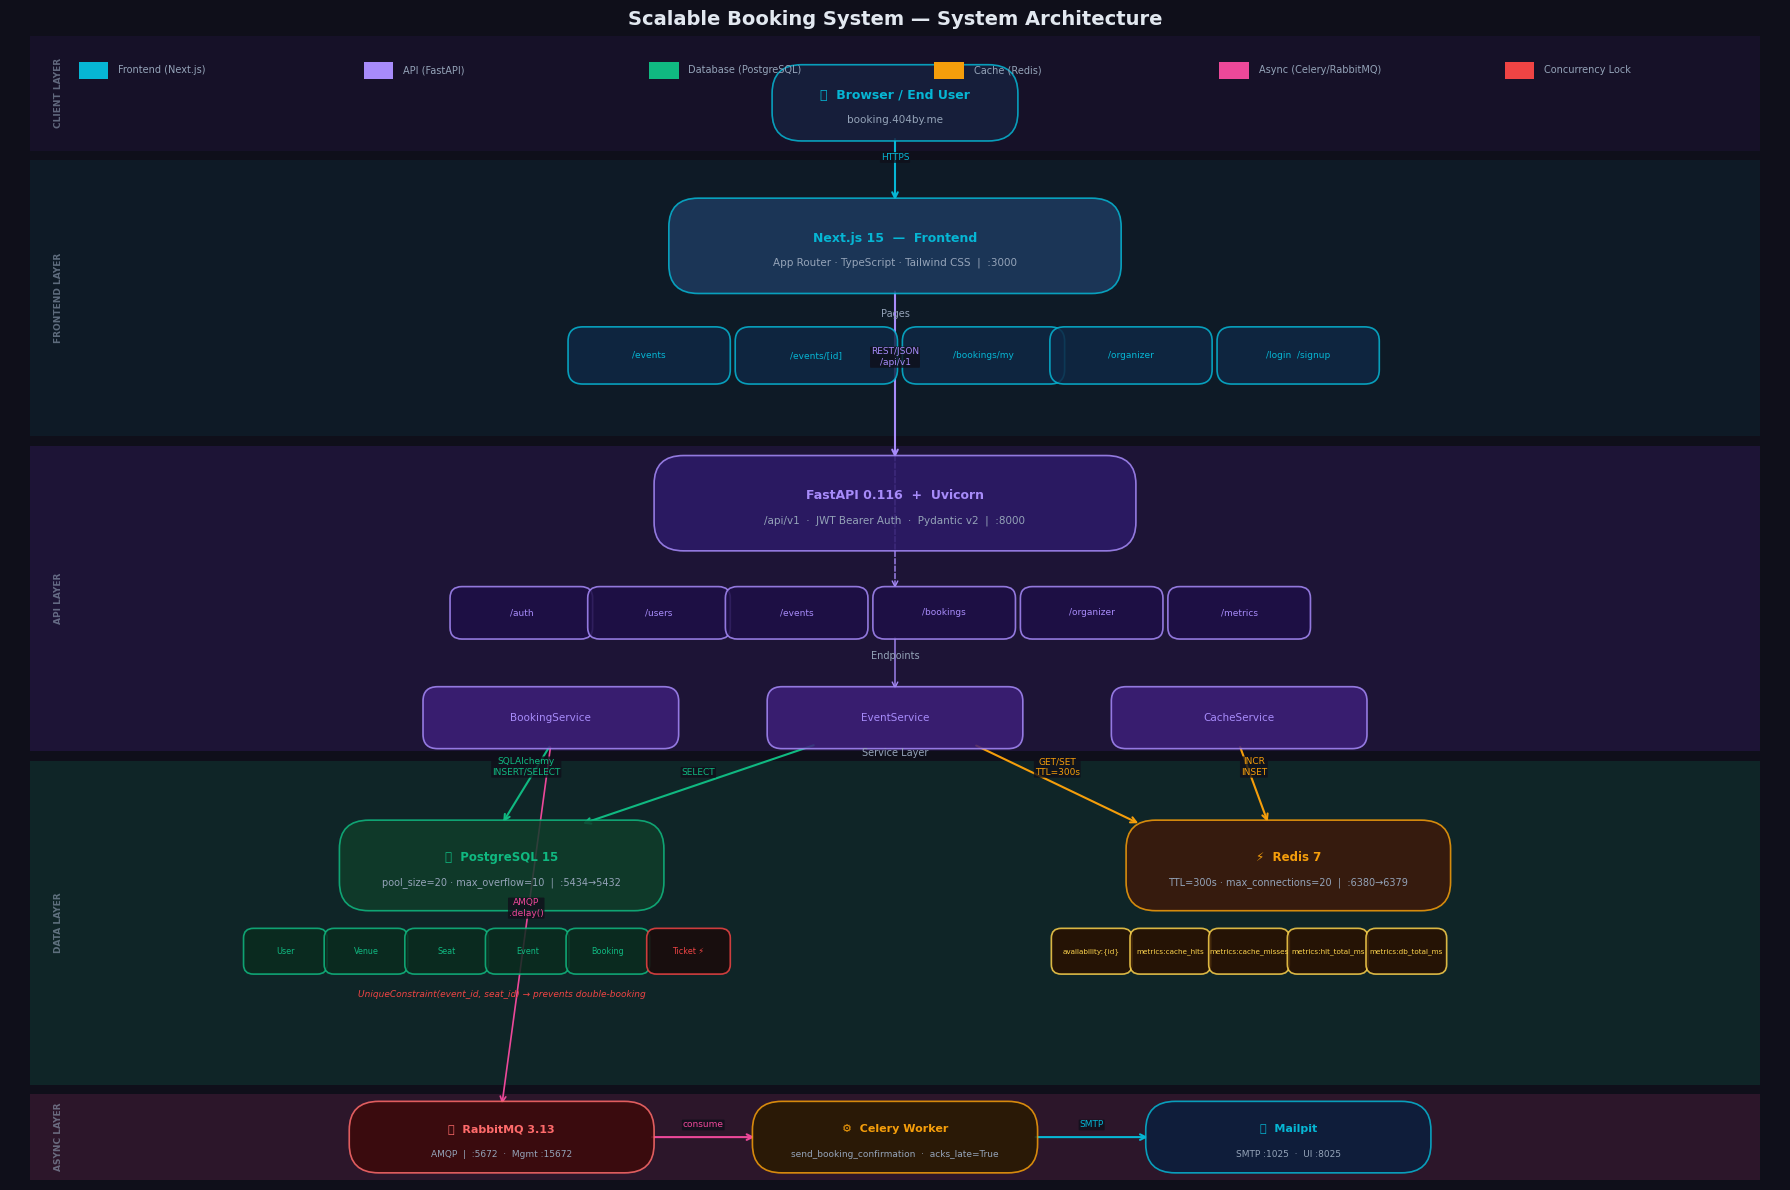

✅ Saved architecture_diagram.png


In [2]:
fig, ax = plt.subplots(figsize=(18, 12))
ax.set_xlim(0, 18)
ax.set_ylim(0, 12)
ax.axis('off')
fig.patch.set_facecolor(BG)

# ── Layer background bands ────────────────────────────────────────────────────
layer_bands = [
    (10.8, 12.0, '#7C3AED11', 'CLIENT LAYER'),
    (7.8,  10.7, '#06B6D411', 'FRONTEND LAYER'),
    (4.5,   7.7, '#7C3AED22', 'API LAYER'),
    (1.0,   4.4, '#10B98122', 'DATA LAYER'),
    (0.0,   0.9, '#EC489922', 'ASYNC LAYER'),
]
for y0, y1, color, lbl in layer_bands:
    ax.add_patch(plt.Rectangle((0.2, y0), 17.6, y1-y0,
                               facecolor=color, edgecolor='none', zorder=0))
    ax.text(0.45, (y0+y1)/2, lbl, va='center', ha='left',
            fontsize=6.5, color=TEXT_DIM, fontweight='bold',
            rotation=90, alpha=0.6)

# ── 1. Browser / User (client layer) ─────────────────────────────────────────
draw_box(ax, 9, 11.3, 2.4, 0.7, '🌐  Browser / End User',
         sublabel='booking.404by.me', color=SURFACE2, text_color=CYAN, fontsize=9, bold=True)

# ── 2. Next.js Frontend ───────────────────────────────────────────────────────
draw_box(ax, 9, 9.8, 4.5, 0.9, 'Next.js 15  —  Frontend',
         sublabel='App Router · TypeScript · Tailwind CSS  |  :3000',
         color='#1E3A5F', text_color=CYAN, fontsize=9, bold=True)

# sub-boxes: pages
pages = [('/events', 6.5), ('/events/[id]', 8.2), ('/bookings/my', 9.9),
         ('/organizer', 11.4), ('/login  /signup', 13.1)]
for lbl, px in pages:
    draw_box(ax, px, 8.65, 1.55, 0.5, lbl, color='#0F2744',
             text_color=CYAN, fontsize=6.5, radius=0.15)
ax.text(9, 9.08, 'Pages', ha='center', va='center', fontsize=7, color=TEXT_DIM)

# ── 3. FastAPI Backend ────────────────────────────────────────────────────────
draw_box(ax, 9, 7.1, 4.8, 0.9, 'FastAPI 0.116  +  Uvicorn',
         sublabel='/api/v1  ·  JWT Bearer Auth  ·  Pydantic v2  |  :8000',
         color='#2D1B69', text_color=VIOLET_LT, fontsize=9, bold=True)

# API route boxes
routes = [('/auth', 5.2), ('/users', 6.6), ('/events', 8.0),
          ('/bookings', 9.5), ('/organizer', 11.0), ('/metrics', 12.5)]
for lbl, rx in routes:
    draw_box(ax, rx, 5.95, 1.35, 0.45, lbl, color='#1E0F47',
             text_color=VIOLET_LT, fontsize=6.5, radius=0.12)
ax.text(9, 5.5, 'Endpoints', ha='center', va='center', fontsize=7, color=TEXT_DIM)

# Services layer
services = [('BookingService', 5.5), ('EventService', 9.0), ('CacheService', 12.5)]
for lbl, sx in services:
    draw_box(ax, sx, 4.85, 2.5, 0.55, lbl, color='#3D1F7A',
             text_color=VIOLET_LT, fontsize=7.5, radius=0.15)
ax.text(9, 4.48, 'Service Layer', ha='center', va='center', fontsize=7, color=TEXT_DIM)

# ── 4. PostgreSQL ─────────────────────────────────────────────────────────────
draw_box(ax, 5, 3.3, 3.2, 0.85, '🐘  PostgreSQL 15',
         sublabel='pool_size=20 · max_overflow=10  |  :5434→5432',
         color='#0F3D2A', text_color=GREEN, fontsize=8.5, bold=True)

# DB table badges
tables = ['User', 'Venue', 'Seat', 'Event', 'Booking', 'Ticket ⚡']
for i, t in enumerate(tables):
    tx = 2.8 + i * 0.82
    draw_box(ax, tx, 2.4, 0.75, 0.38, t,
             color='#0A2B1E' if '⚡' not in t else '#1A0A0A',
             text_color=GREEN if '⚡' not in t else RED,
             fontsize=5.8, radius=0.1)
ax.text(5, 1.95, 'UniqueConstraint(event_id, seat_id) → prevents double-booking',
        ha='center', va='center', fontsize=6.5, color=RED,
        style='italic')

# ── 5. Redis ──────────────────────────────────────────────────────────────────
draw_box(ax, 13, 3.3, 3.2, 0.85, '⚡  Redis 7',
         sublabel='TTL=300s · max_connections=20  |  :6380→6379',
         color='#3D1A0A', text_color=GOLD, fontsize=8.5, bold=True)

redis_keys = ['availability:{id}', 'metrics:cache_hits', 'metrics:cache_misses',
              'metrics:hit_total_ms', 'metrics:db_total_ms']
for i, k in enumerate(redis_keys):
    kx = 11.0 + i * 0.8
    draw_box(ax, kx, 2.4, 0.72, 0.38, k,
             color='#2A1000', text_color=GOLD_LT, fontsize=5.2, radius=0.1)

# ── 6. RabbitMQ ───────────────────────────────────────────────────────────────
draw_box(ax, 5, 0.45, 3.0, 0.65, '🐰  RabbitMQ 3.13',
         sublabel='AMQP  |  :5672  ·  Mgmt :15672',
         color='#3D0A0A', text_color='#FF6B6B', fontsize=8, bold=True)

# ── 7. Celery Worker ─────────────────────────────────────────────────────────
draw_box(ax, 9, 0.45, 2.8, 0.65, '⚙  Celery Worker',
         sublabel='send_booking_confirmation  ·  acks_late=True',
         color='#2A1A00', text_color=GOLD, fontsize=8, bold=True)

# ── 8. Mailpit ────────────────────────────────────────────────────────────────
draw_box(ax, 13, 0.45, 2.8, 0.65, '📧  Mailpit',
         sublabel='SMTP :1025  ·  UI :8025',
         color='#0A1F3D', text_color=CYAN, fontsize=8, bold=True)

# ─────────────────────────────────────────────────────────────────────────────
# ARROWS
# ─────────────────────────────────────────────────────────────────────────────

# Browser → Next.js
arrow(ax, 9, 10.95, 9, 10.25, 'HTTPS', color=CYAN)

# Next.js → FastAPI
arrow(ax, 9, 9.35, 9, 7.55, 'REST/JSON\n/api/v1', color=VIOLET_LT)

# Pages → route boxes (just a general arrow)
ax.annotate('', xy=(9, 6.18), xytext=(9, 8.4),
            arrowprops=dict(arrowstyle='->', color=VIOLET_LT, lw=1.0,
                            linestyle='dashed'), zorder=2)

# Endpoints → services
ax.annotate('', xy=(9, 5.12), xytext=(9, 5.72),
            arrowprops=dict(arrowstyle='->', color=VIOLET_LT, lw=1.0), zorder=2)

# BookingService → PostgreSQL
arrow(ax, 5.5, 4.57, 5.0, 3.73, 'SQLAlchemy\nINSERT/SELECT', color=GREEN)

# EventService → PostgreSQL  
arrow(ax, 8.2, 4.57, 5.8, 3.73, 'SELECT', color=GREEN)

# EventService → Redis (cache check)
arrow(ax, 9.8, 4.57, 11.5, 3.73, 'GET/SET\nTTL=300s', color=GOLD)

# CacheService → Redis
arrow(ax, 12.5, 4.57, 12.8, 3.73, 'INCR\nINSET', color=GOLD)

# BookingService → RabbitMQ
arrow(ax, 5.5, 4.57, 5.0, 0.77, 'AMQP\n.delay()', color=PINK, lw=1.2)

# RabbitMQ → Celery Worker
arrow(ax, 6.5, 0.45, 7.6, 0.45, 'consume', color=PINK)

# Celery Worker → Mailpit
arrow(ax, 10.4, 0.45, 11.6, 0.45, 'SMTP', color=CYAN)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    (CYAN, 'Frontend (Next.js)'), (VIOLET_LT, 'API (FastAPI)'),
    (GREEN, 'Database (PostgreSQL)'), (GOLD, 'Cache (Redis)'),
    (PINK, 'Async (Celery/RabbitMQ)'), (RED, 'Concurrency Lock'),
]
for i, (c, lbl) in enumerate(legend_items):
    lx = 0.7 + i * 2.9
    ax.add_patch(plt.Rectangle((lx, 11.55), 0.3, 0.18, facecolor=c, zorder=5))
    ax.text(lx + 0.4, 11.64, lbl, va='center', fontsize=7, color=TEXT_DIM)

ax.set_title('Scalable Booking System — System Architecture',
             fontsize=14, color=TEXT, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('architecture_diagram.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅ Saved architecture_diagram.png')

## 2 · Booking Request Flow — Swimlane Diagram

End-to-end trace of a `POST /api/v1/bookings` request through every system layer, showing the happy path and the concurrency-conflict path.

/tmp/ipykernel_477770/375588677.py:108: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/375588677.py:108: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/375588677.py:108: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/375588677.py:108: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/375588677.py:108: UserWarning: Glyph 128024 (\N{ELEPHANT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/375588677.py:108: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/375588677.py:109: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('request_flow_s

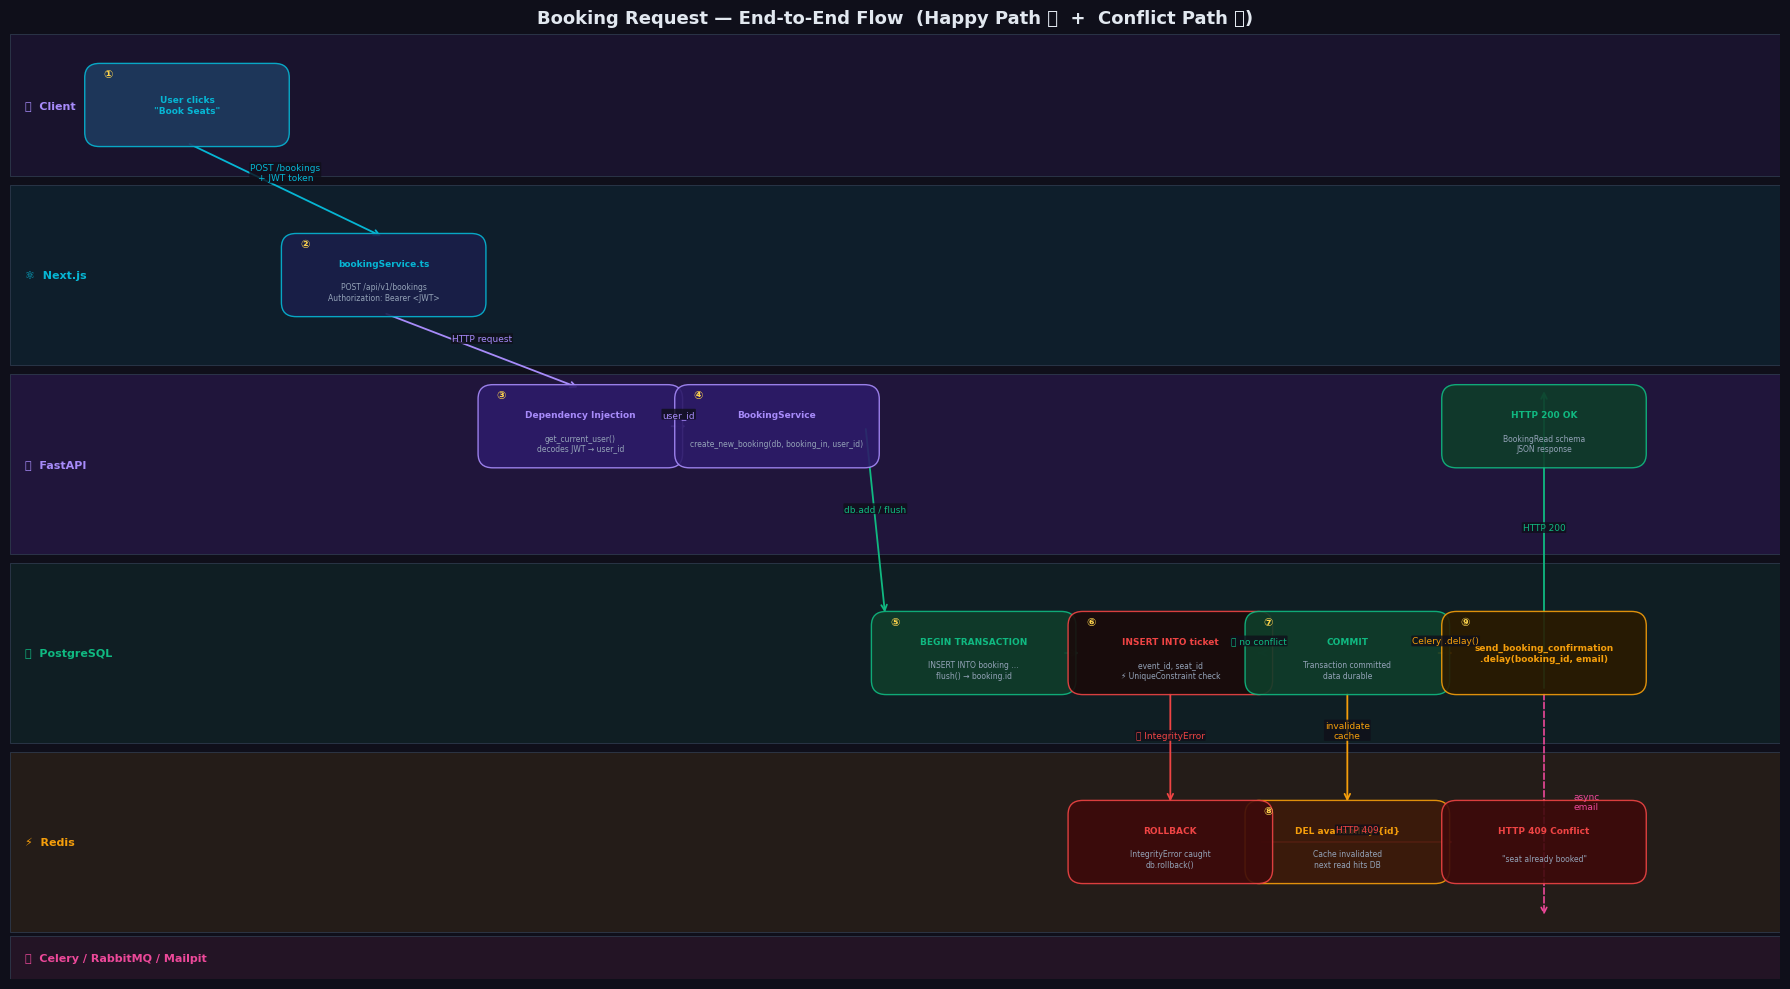

✅ Saved request_flow_swimlane.png


In [3]:
fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 18)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor(BG)

# ── Swim lanes ────────────────────────────────────────────────────────────────
lanes = [
    (8.5, 10.0, '#7C3AED18', '🌐  Client'),
    (6.5,  8.4, '#06B6D418', '⚛  Next.js'),
    (4.5,  6.4, '#7C3AED28', '🚀  FastAPI'),
    (2.5,  4.4, '#10B98118', '🐘  PostgreSQL'),
    (0.5,  2.4, '#F59E0B18', '⚡  Redis'),
]
lane_colors = [VIOLET_LT, CYAN, VIOLET_LT, GREEN, GOLD]

for (y0, y1, bg, lbl), lc in zip(lanes, lane_colors):
    ax.add_patch(plt.Rectangle((0, y0), 18, y1-y0,
                               facecolor=bg, edgecolor=BORDER, linewidth=0.5, zorder=0))
    ax.text(0.15, (y0+y1)/2, lbl, va='center', ha='left',
            fontsize=8, color=lc, fontweight='bold')

# Async lane at far right
ax.add_patch(plt.Rectangle((0, 0), 18, 0.45, facecolor='#EC489918',
                            edgecolor=BORDER, linewidth=0.5, zorder=0))
ax.text(0.15, 0.22, '📧  Celery / RabbitMQ / Mailpit', va='center',
        ha='left', fontsize=8, color=PINK, fontweight='bold')

# ── Step boxes ────────────────────────────────────────────────────────────────
# (x, y, label, sublabel, color, text_color)
steps = [
    # Client
    (1.8, 9.25, 'User clicks\n"Book Seats"',   '',                  '#1E3A5F', CYAN),
    # Next.js
    (3.8, 7.45, 'bookingService.ts',            'POST /api/v1/bookings\nAuthorization: Bearer <JWT>',  '#1A1F4A', CYAN),
    # FastAPI — auth
    (5.8, 5.85, 'Dependency Injection',         'get_current_user()\ndecodes JWT → user_id',           '#2D1B69', VIOLET_LT),
    # FastAPI — service call
    (7.8, 5.85, 'BookingService',               'create_new_booking(db, booking_in, user_id)',          '#2D1B69', VIOLET_LT),
    # PostgreSQL — begin
    (9.8, 3.45, 'BEGIN TRANSACTION',            'INSERT INTO booking …\nflush() → booking.id',          '#0F3D2A', GREEN),
    # PostgreSQL — ticket insert
    (11.8, 3.45, 'INSERT INTO ticket',           'event_id, seat_id\n⚡ UniqueConstraint check',         '#1A0A0A', RED),
    # Branching: success vs conflict
    # success path
    (13.6, 3.45, 'COMMIT',                       'Transaction committed\ndata durable',                 '#0F3D2A', GREEN),
    # Redis invalidate
    (13.6, 1.45, 'DEL availability:{id}',        'Cache invalidated\nnext read hits DB',                '#3D1A0A', GOLD),
    # async publish
    (15.6, 3.45, 'send_booking_confirmation\n.delay(booking_id, email)', '', '#2A1A00', GOLD),
    # conflict path
    (11.8, 1.45, 'ROLLBACK',                     'IntegrityError caught\ndb.rollback()',                 '#3D0A0A', RED),
    # response
    (15.6, 1.45, 'HTTP 409 Conflict',            '"seat already booked"',                               '#3D0A0A', RED),
    (15.6, 5.85, 'HTTP 200 OK',                   'BookingRead schema\nJSON response',                   '#0F3D2A', GREEN),
]

box_w, box_h = 2.0, 0.8
for x, y, lbl, sub, bg, tc in steps:
    box = FancyBboxPatch((x - box_w/2, y - box_h/2), box_w, box_h,
                         boxstyle='round,pad=0.04,rounding_size=0.15',
                         facecolor=bg, edgecolor=tc, linewidth=1.0, alpha=0.9, zorder=3)
    ax.add_patch(box)
    if sub:
        ax.text(x, y + 0.12, lbl, ha='center', va='center', fontsize=6.5,
                color=tc, fontweight='bold', zorder=4)
        ax.text(x, y - 0.18, sub, ha='center', va='center', fontsize=5.5,
                color=TEXT_DIM, zorder=4)
    else:
        ax.text(x, y, lbl, ha='center', va='center', fontsize=6.5,
                color=tc, fontweight='bold', zorder=4)

# Step number badges
step_nums = ['①', '②', '③', '④', '⑤', '⑥', '⑦', '⑧', '⑨']
coords = [(1.8,9.25),(3.8,7.45),(5.8,5.85),(7.8,5.85),(9.8,3.45),
          (11.8,3.45),(13.6,3.45),(13.6,1.45),(15.6,3.45)]
for n, (x, y) in zip(step_nums, coords):
    ax.text(x - 0.85, y + 0.3, n, fontsize=8, color=GOLD_LT, fontweight='bold', zorder=5)

# ── Flow arrows ───────────────────────────────────────────────────────────────
flow_arrows = [
    (1.8, 8.85, 3.8, 7.85, CYAN, 'POST /bookings\n+ JWT token'),
    (3.8, 7.05, 5.8, 6.25, VIOLET_LT, 'HTTP request'),
    (5.8+0.9, 5.85, 7.8-0.9, 5.85, VIOLET_LT, 'user_id'),
    (7.8+0.9, 5.85, 9.8-0.9, 3.85, GREEN, 'db.add / flush'),
    (9.8+0.9, 3.45, 11.8-0.9, 3.45, GREEN, ''),
    # success branch
    (11.8+0.9, 3.45, 13.6-0.9, 3.45, GREEN, '✅ no conflict'),
    (13.6, 3.05, 13.6, 1.85, GOLD, 'invalidate\ncache'),
    (13.6+0.9, 3.45, 15.6-0.9, 3.45, GOLD, 'Celery .delay()'),
    (15.6, 3.05, 15.6, 6.25, GREEN, 'HTTP 200'),
    # conflict branch (below)
    (11.8, 3.05, 11.8, 1.85, RED, '❌ IntegrityError'),
    (11.8+0.9, 1.45, 15.6-0.9, 1.45, RED, 'HTTP 409'),
]
for x1, y1, x2, y2, c, lbl in flow_arrows:
    arrow(ax, x1, y1, x2, y2, lbl, color=c, lw=1.3)

# Async lane arrow
ax.annotate('', xy=(15.6, 0.65), xytext=(15.6, 3.05),
            arrowprops=dict(arrowstyle='->', color=PINK, lw=1.2,
                            linestyle='dashed'), zorder=2)
ax.text(15.9, 1.8, 'async\nemail', ha='left', fontsize=6.5, color=PINK)

ax.set_title('Booking Request — End-to-End Flow  (Happy Path ✅  +  Conflict Path ❌)',
             fontsize=13, color=TEXT, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('request_flow_swimlane.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅ Saved request_flow_swimlane.png')

## 3 · Entity Relationship Diagram (ERD)

All 6 database models with their columns, types, and relationships.
The `Ticket` table highlighted in red is where the **concurrency lock** lives.

/tmp/ipykernel_477770/4115591642.py:135: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/4115591642.py:135: UserWarning: Glyph 127967 (\N{STADIUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/4115591642.py:135: UserWarning: Glyph 128186 (\N{SEAT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/4115591642.py:135: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/4115591642.py:135: UserWarning: Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/4115591642.py:135: UserWarning: Glyph 127915 (\N{TICKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/4115591642.py:135: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/

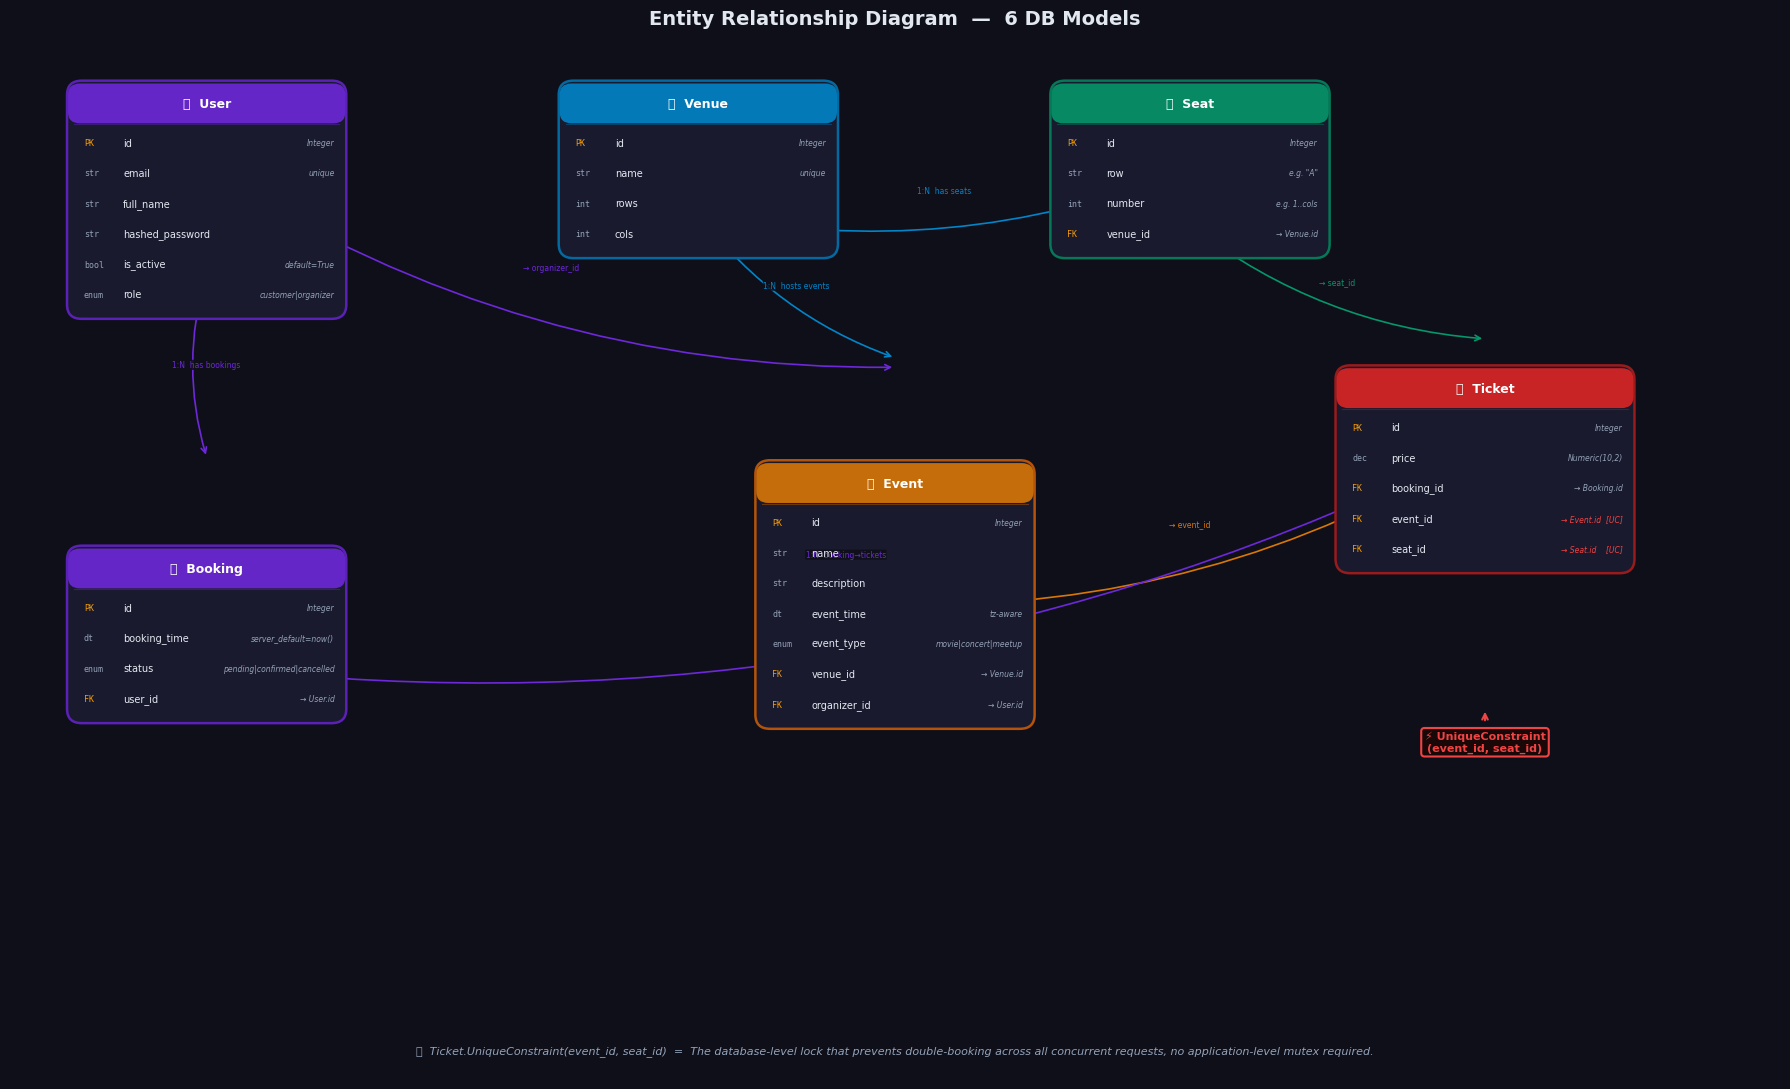

✅ Saved erd_diagram.png


In [4]:
fig, ax = plt.subplots(figsize=(18, 11))
ax.set_xlim(0, 18)
ax.set_ylim(0, 11)
ax.axis('off')
fig.patch.set_facecolor(BG)

def draw_entity(ax, x, y, title, fields, color=VIOLET, header_color=None,
                width=2.8, row_h=0.32):
    """Draw a UML-style entity box with header and field rows."""
    if header_color is None:
        header_color = color
    n = len(fields)
    total_h = 0.45 + n * row_h + 0.1  # header + rows + padding
    left = x - width/2
    top = y

    # Outer border
    outer = FancyBboxPatch((left, top - total_h), width, total_h,
                           boxstyle='round,pad=0.02,rounding_size=0.15',
                           facecolor=SURFACE, edgecolor=color, linewidth=1.8, zorder=3)
    ax.add_patch(outer)

    # Header
    header = FancyBboxPatch((left, top - 0.42), width, 0.40,
                            boxstyle='round,pad=0.01,rounding_size=0.12',
                            facecolor=header_color, edgecolor='none', alpha=0.9, zorder=4)
    ax.add_patch(header)
    ax.text(x, top - 0.22, title, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold', zorder=5)

    # Separator line
    ax.plot([left + 0.05, left + width - 0.05], [top - 0.44, top - 0.44],
            color=color, lw=0.8, alpha=0.5, zorder=4)

    # Field rows
    for i, (ftype, fname, note) in enumerate(fields):
        fy = top - 0.44 - (i + 0.6) * row_h
        type_color = GOLD if ftype in ('PK', 'FK') else TEXT_DIM
        ax.text(left + 0.15, fy, ftype, ha='left', va='center',
                fontsize=6, color=type_color, fontfamily='monospace', zorder=5)
        ax.text(left + 0.55, fy, fname, ha='left', va='center',
                fontsize=7, color=TEXT, zorder=5)
        if note:
            ax.text(left + width - 0.1, fy, note, ha='right', va='center',
                    fontsize=5.5, color=RED if 'UC' in note else TEXT_DIM,
                    style='italic', zorder=5)
    return total_h

# ── Entity data ───────────────────────────────────────────────────────────────
user_fields = [
    ('PK', 'id', 'Integer'),
    ('str', 'email', 'unique'),
    ('str', 'full_name', ''),
    ('str', 'hashed_password', ''),
    ('bool', 'is_active', 'default=True'),
    ('enum', 'role', 'customer|organizer'),
]
venue_fields = [
    ('PK', 'id', 'Integer'),
    ('str', 'name', 'unique'),
    ('int', 'rows', ''),
    ('int', 'cols', ''),
]
seat_fields = [
    ('PK', 'id', 'Integer'),
    ('str', 'row', 'e.g. "A"'),
    ('int', 'number', 'e.g. 1..cols'),
    ('FK', 'venue_id', '→ Venue.id'),
]
event_fields = [
    ('PK', 'id', 'Integer'),
    ('str', 'name', ''),
    ('str', 'description', ''),
    ('dt', 'event_time', 'tz-aware'),
    ('enum', 'event_type', 'movie|concert|meetup'),
    ('FK', 'venue_id', '→ Venue.id'),
    ('FK', 'organizer_id', '→ User.id'),
]
booking_fields = [
    ('PK', 'id', 'Integer'),
    ('dt', 'booking_time', 'server_default=now()'),
    ('enum', 'status', 'pending|confirmed|cancelled'),
    ('FK', 'user_id', '→ User.id'),
]
ticket_fields = [
    ('PK', 'id', 'Integer'),
    ('dec', 'price', 'Numeric(10,2)'),
    ('FK', 'booking_id', '→ Booking.id'),
    ('FK', 'event_id', '→ Event.id  [UC]'),
    ('FK', 'seat_id', '→ Seat.id    [UC]'),
]

# ── Draw all entities ─────────────────────────────────────────────────────────
#  Layout:  User(2,10)  Venue(7,10)  Seat(12,10)
#           Booking(2,6)  Event(9,6.5)  Ticket(15,7)
draw_entity(ax, 2,   10.5, '👤  User',    user_fields,    color='#5B21B6', header_color='#6D28D9')
draw_entity(ax, 7,   10.5, '🏟  Venue',   venue_fields,   color='#0369A1', header_color='#0284C7')
draw_entity(ax, 12,  10.5, '💺  Seat',    seat_fields,    color='#047857', header_color='#059669')
draw_entity(ax, 2,    5.6, '📋  Booking', booking_fields, color='#5B21B6', header_color='#6D28D9')
draw_entity(ax, 9.0,  6.5, '🎭  Event',   event_fields,   color='#B45309', header_color='#D97706')
draw_entity(ax, 15,   7.5, '🎫  Ticket', ticket_fields,  color='#991B1B', header_color='#DC2626', width=3.0)

# UC annotation for Ticket
ax.text(15, 3.55, '⚡ UniqueConstraint\n(event_id, seat_id)', ha='center', va='center',
        fontsize=8, color=RED, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A0808', edgecolor=RED, linewidth=1.5))
ax.annotate('', xy=(15, 3.9), xytext=(15, 3.75),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))

# ── Relationship arrows ───────────────────────────────────────────────────────
rels = [
    # (x1, y1, x2, y2, label, color)
    (2,    8.5,  2,    6.55,  '1:N  has bookings',   '#6D28D9'),
    (7,    9.12, 12,   9.6,   '1:N  has seats',       '#0284C7'),
    (7,    9.12, 9.0,  7.6,   '1:N  hosts events',    '#0284C7'),
    (12,   9.0,  15,   7.8,   '→ seat_id',            '#059669'),
    (9.0,  5.0,  15,   6.7,   '→ event_id',           '#D97706'),
    (2,    4.35, 15,   6.7,   '1:N  booking→tickets', '#6D28D9'),
    (2,    9.6,  9.0,  7.5,   '→ organizer_id',       '#6D28D9'),
]
for x1, y1, x2, y2, lbl, c in rels:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.2,
                                connectionstyle='arc3,rad=0.15'), zorder=2)
    mx, my = (x1+x2)/2, (y1+y2)/2
    ax.text(mx, my, lbl, ha='center', va='center', fontsize=5.5, color=c,
            bbox=dict(boxstyle='round,pad=0.08', facecolor=BG, edgecolor='none', alpha=0.85))

ax.set_title('Entity Relationship Diagram  —  6 DB Models',
             fontsize=14, color=TEXT, fontweight='bold', pad=8)
ax.text(9, 0.3, '🔴  Ticket.UniqueConstraint(event_id, seat_id)  =  The database-level lock that prevents double-booking '
        'across all concurrent requests, no application-level mutex required.',
        ha='center', va='center', fontsize=8, color=TEXT_DIM, style='italic')

plt.tight_layout()
plt.savefig('erd_diagram.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅ Saved erd_diagram.png')

## 4 · Technology Stack — Layer Breakdown

/tmp/ipykernel_477770/3177156645.py:92: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/3177156645.py:92: UserWarning: Glyph 128024 (\N{ELEPHANT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/3177156645.py:92: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/3177156645.py:92: UserWarning: Glyph 128048 (\N{RABBIT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/3177156645.py:92: UserWarning: Glyph 128231 (\N{E-MAIL SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/3177156645.py:93: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig('stack_and_services.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_477770/3177156645.py:93: UserWarning: Glyph 128024 (\N{ELEPHANT}) missing from font(s) DejaVu Sans.
  plt.savefig('

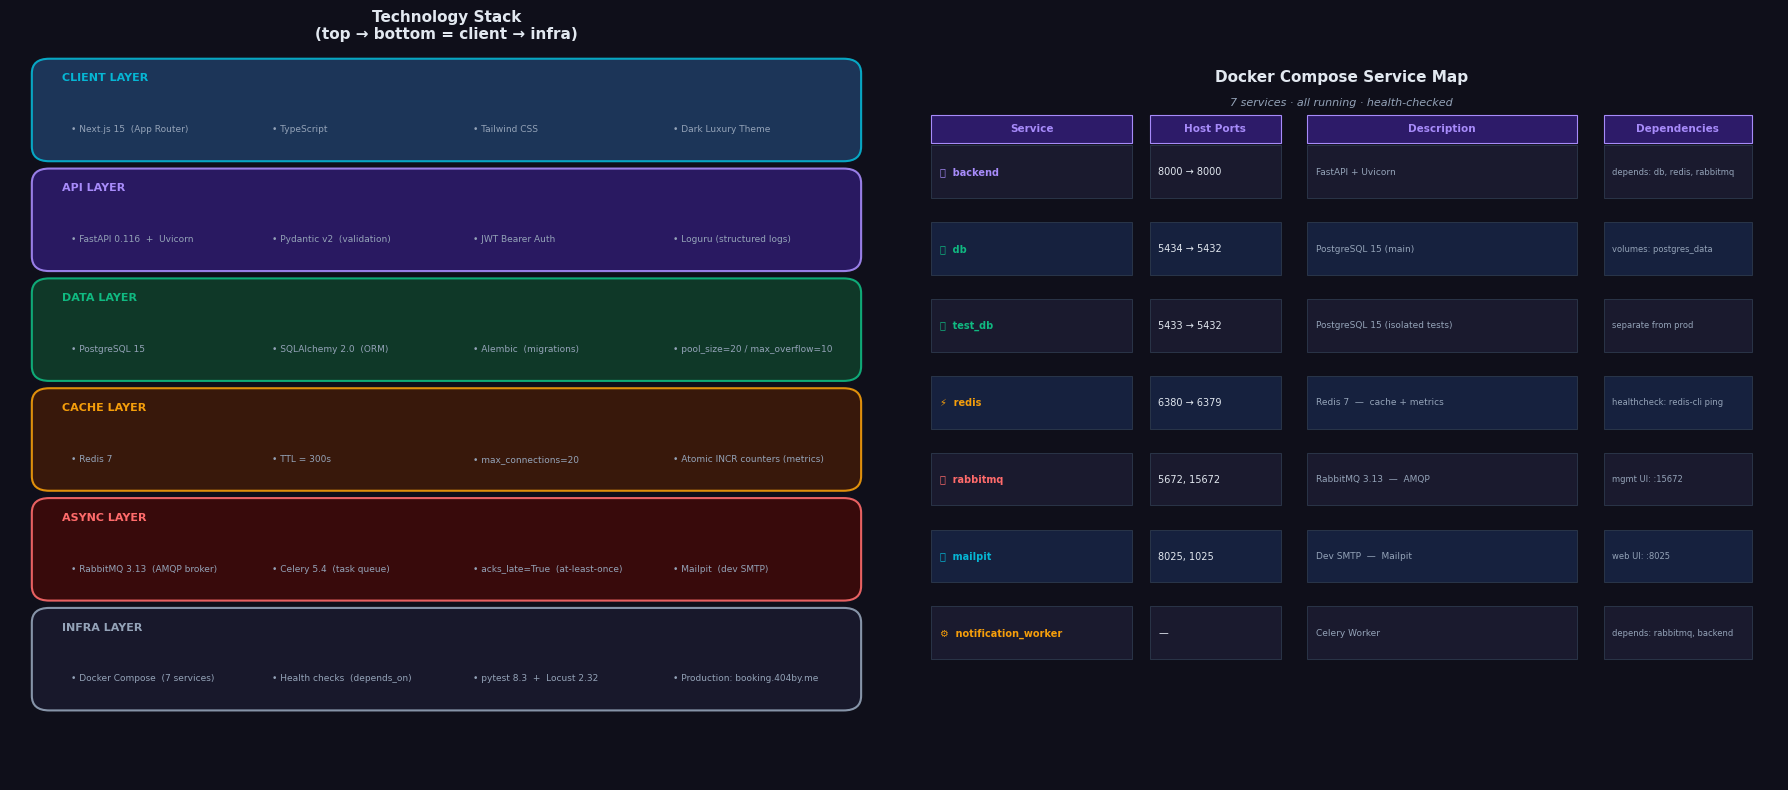

✅ Saved stack_and_services.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor(BG)

# ── Left: Layered stack visual ────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(BG)
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

stack_layers = [
    # (y_bottom, height, color, layer_name, items)
    (8.5, 1.3, '#1E3A5F', CYAN,      'CLIENT LAYER',
     ['Next.js 15  (App Router)', 'TypeScript', 'Tailwind CSS', 'Dark Luxury Theme']),
    (7.0, 1.3, '#2D1B69', VIOLET_LT, 'API LAYER',
     ['FastAPI 0.116  +  Uvicorn', 'Pydantic v2  (validation)', 'JWT Bearer Auth', 'Loguru (structured logs)']),
    (5.5, 1.3, '#0F3D2A', GREEN,     'DATA LAYER',
     ['PostgreSQL 15', 'SQLAlchemy 2.0  (ORM)', 'Alembic  (migrations)', 'pool_size=20 / max_overflow=10']),
    (4.0, 1.3, '#3D1A0A', GOLD,      'CACHE LAYER',
     ['Redis 7', 'TTL = 300s', 'max_connections=20', 'Atomic INCR counters (metrics)']),
    (2.5, 1.3, '#3D0A0A', '#FF6B6B', 'ASYNC LAYER',
     ['RabbitMQ 3.13  (AMQP broker)', 'Celery 5.4  (task queue)', 'acks_late=True  (at-least-once)', 'Mailpit  (dev SMTP)']),
    (1.0, 1.3, '#1A1A2E', TEXT_DIM,  'INFRA LAYER',
     ['Docker Compose  (7 services)', 'Health checks  (depends_on)', 'pytest 8.3  +  Locust 2.32', 'Production: booking.404by.me']),
]

for y0, h, bg, tc, name, items in stack_layers:
    # Layer background
    ax.add_patch(FancyBboxPatch((0.3, y0), 9.4, h,
                                boxstyle='round,pad=0.05,rounding_size=0.2',
                                facecolor=bg, edgecolor=tc, linewidth=1.5, alpha=0.9, zorder=2))
    # Layer name
    ax.text(0.6, y0 + h - 0.22, name, ha='left', va='center',
            fontsize=8, color=tc, fontweight='bold', zorder=3)
    # Items
    for j, item in enumerate(items):
        ix = 0.7 + j * 2.3
        ax.text(ix, y0 + 0.38, f'• {item}', ha='left', va='center',
                fontsize=6.5, color=TEXT_DIM, zorder=3)

ax.set_title('Technology Stack\n(top → bottom = client → infra)',
             fontsize=11, color=TEXT, fontweight='bold')

# ── Right: Service port map ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

services_data = [
    ('🚀  backend',           '8000 → 8000',   'FastAPI + Uvicorn',           VIOLET_LT, 'depends: db, redis, rabbitmq'),
    ('🐘  db',                '5434 → 5432',   'PostgreSQL 15 (main)',         GREEN,     'volumes: postgres_data'),
    ('🧪  test_db',           '5433 → 5432',   'PostgreSQL 15 (isolated tests)',GREEN,    'separate from prod'),
    ('⚡  redis',             '6380 → 6379',   'Redis 7  —  cache + metrics',  GOLD,      'healthcheck: redis-cli ping'),
    ('🐰  rabbitmq',          '5672, 15672',   'RabbitMQ 3.13  —  AMQP',      '#FF6B6B', 'mgmt UI: :15672'),
    ('📧  mailpit',           '8025, 1025',    'Dev SMTP  —  Mailpit',         CYAN,      'web UI: :8025'),
    ('⚙  notification_worker','—',             'Celery Worker',                GOLD,      'depends: rabbitmq, backend'),
]

ax2.text(5, 9.6, 'Docker Compose Service Map', ha='center', va='center',
         fontsize=11, color=TEXT, fontweight='bold')
ax2.text(5, 9.25, '7 services · all running · health-checked', ha='center', va='center',
         fontsize=8, color=TEXT_DIM, style='italic')

cols = ['Service', 'Host Ports', 'Description', 'Dependencies']
col_x = [0.3, 2.8, 4.6, 8.0]
col_w = [2.4, 1.6, 3.2, 1.8]

# Header
for cx, cw, col in zip(col_x, col_w, cols):
    ax2.add_patch(plt.Rectangle((cx, 8.7), cw - 0.1, 0.38,
                                facecolor='#2D1B69', edgecolor=VIOLET_LT, linewidth=0.8))
    ax2.text(cx + (cw-0.1)/2, 8.89, col, ha='center', va='center',
             fontsize=7.5, color=VIOLET_LT, fontweight='bold')

# Rows
for i, (name, ports, desc, tc, deps) in enumerate(services_data):
    ry = 8.3 - i * 1.05
    row_bg = '#1A1A2E' if i % 2 == 0 else '#16213E'
    for cx, cw in zip(col_x, col_w):
        ax2.add_patch(plt.Rectangle((cx, ry - 0.35), cw - 0.1, 0.72,
                                    facecolor=row_bg, edgecolor=BORDER, linewidth=0.5))

    row_data = [name, ports, desc, deps]
    row_colors = [tc, TEXT, TEXT_DIM, TEXT_DIM]
    row_sizes = [7, 7, 6.5, 6]
    for cx, cw, val, vc, vs in zip(col_x, col_w, row_data, row_colors, row_sizes):
        ax2.text(cx + 0.1, ry, val, ha='left', va='center',
                 fontsize=vs, color=vc, fontweight='bold' if val == name else 'normal')

plt.tight_layout()
plt.savefig('stack_and_services.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅ Saved stack_and_services.png')

## 5 · Design Decisions — Why Each Choice Was Made

This section documents the **engineering reasoning** behind each architectural decision — critical for SDE-2 interviews.

/tmp/ipykernel_477770/3452442386.py:100: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/3452442386.py:100: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_477770/3452442386.py:101: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('design_decisions.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_477770/3452442386.py:101: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('design_decisions.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_477770/3452442386.py:101: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('design_decisions.png', dpi=150, bbox_inches='tight',
/tmp/ipykernel_477770/3452442386.py:101: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('desi

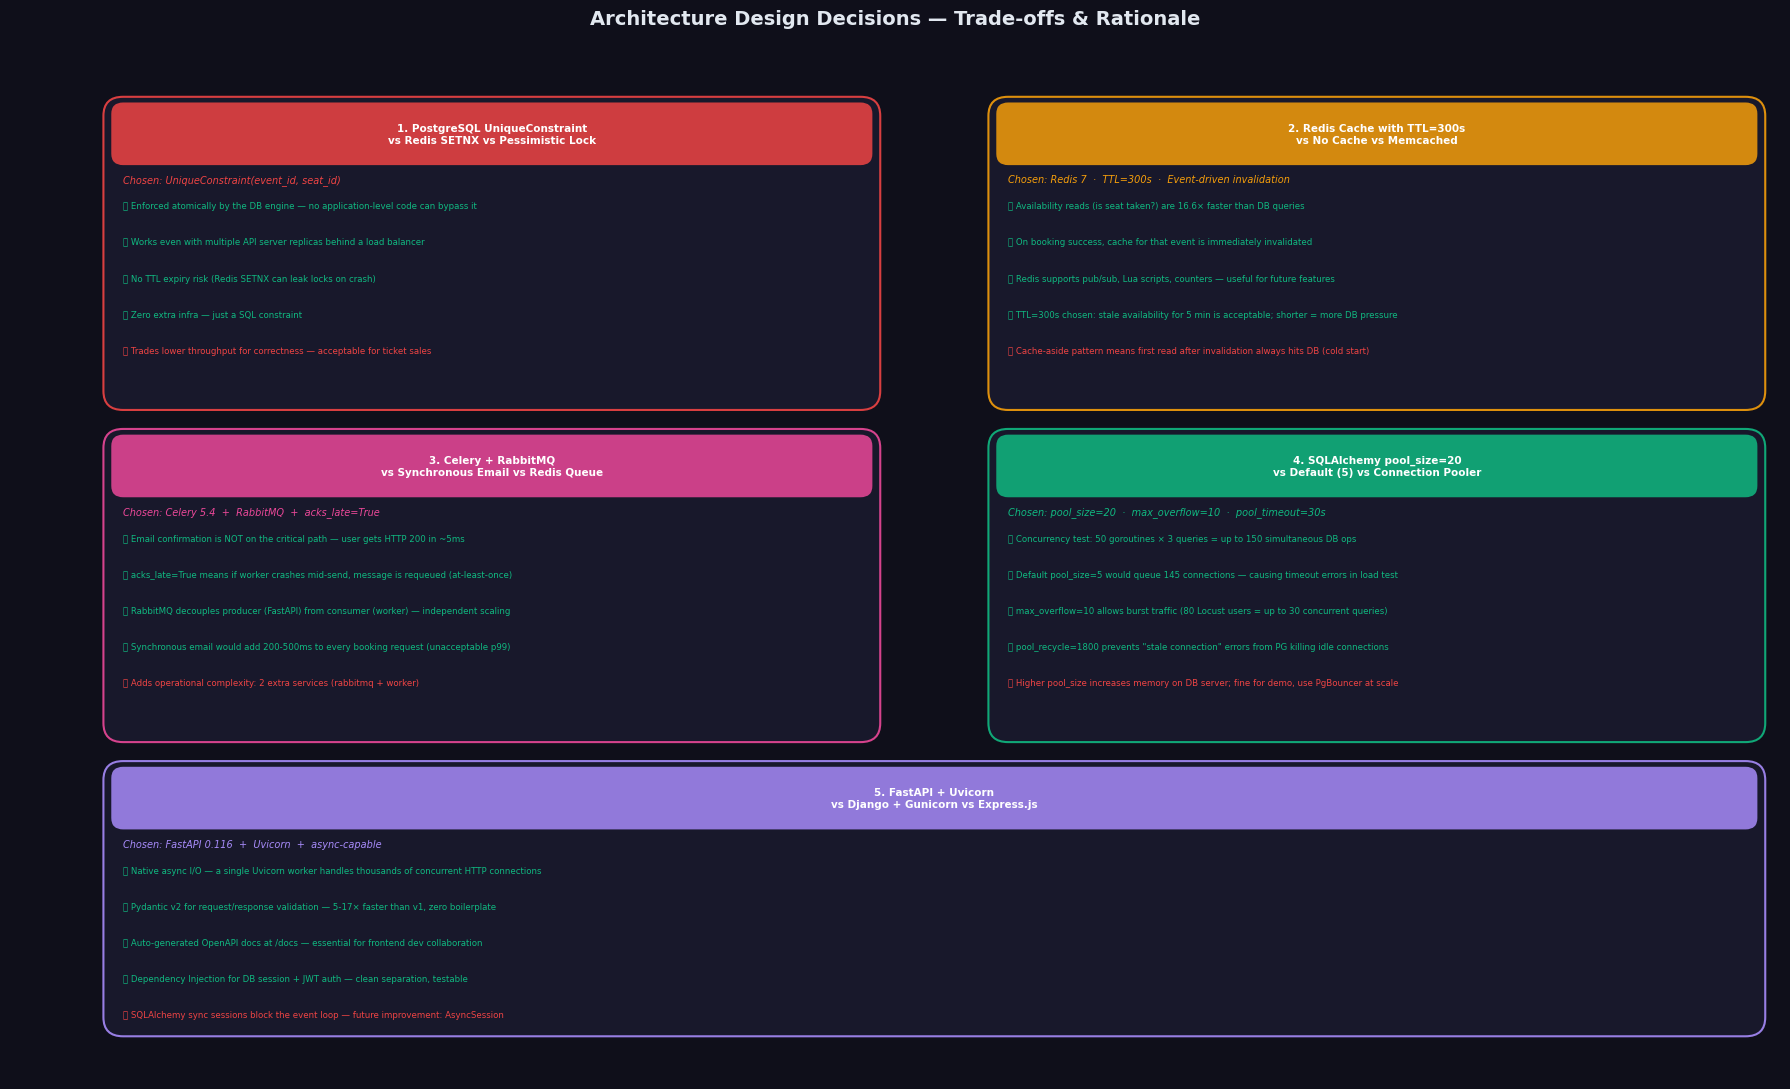

✅ Saved design_decisions.png


In [6]:
fig, ax = plt.subplots(figsize=(18, 11))
ax.set_xlim(0, 18)
ax.set_ylim(0, 11)
ax.axis('off')
fig.patch.set_facecolor(BG)

decisions = [
    {
        'title': '1. PostgreSQL UniqueConstraint\nvs Redis SETNX vs Pessimistic Lock',
        'chosen': 'UniqueConstraint(event_id, seat_id)',
        'why': [
            '✅ Enforced atomically by the DB engine — no application-level code can bypass it',
            '✅ Works even with multiple API server replicas behind a load balancer',
            '✅ No TTL expiry risk (Redis SETNX can leak locks on crash)',
            '✅ Zero extra infra — just a SQL constraint',
            '❌ Trades lower throughput for correctness — acceptable for ticket sales',
        ],
        'color': RED, 'x': 1.0, 'y': 10.3, 'w': 7.8, 'h': 3.2,
    },
    {
        'title': '2. Redis Cache with TTL=300s\nvs No Cache vs Memcached',
        'chosen': 'Redis 7  ·  TTL=300s  ·  Event-driven invalidation',
        'why': [
            '✅ Availability reads (is seat taken?) are 16.6× faster than DB queries',
            '✅ On booking success, cache for that event is immediately invalidated',
            '✅ Redis supports pub/sub, Lua scripts, counters — useful for future features',
            '✅ TTL=300s chosen: stale availability for 5 min is acceptable; shorter = more DB pressure',
            '❌ Cache-aside pattern means first read after invalidation always hits DB (cold start)',
        ],
        'color': GOLD, 'x': 10.0, 'y': 10.3, 'w': 7.8, 'h': 3.2,
    },
    {
        'title': '3. Celery + RabbitMQ\nvs Synchronous Email vs Redis Queue',
        'chosen': 'Celery 5.4  +  RabbitMQ  +  acks_late=True',
        'why': [
            '✅ Email confirmation is NOT on the critical path — user gets HTTP 200 in ~5ms',
            '✅ acks_late=True means if worker crashes mid-send, message is requeued (at-least-once)',
            '✅ RabbitMQ decouples producer (FastAPI) from consumer (worker) — independent scaling',
            '✅ Synchronous email would add 200-500ms to every booking request (unacceptable p99)',
            '❌ Adds operational complexity: 2 extra services (rabbitmq + worker)',
        ],
        'color': PINK, 'x': 1.0, 'y': 6.8, 'w': 7.8, 'h': 3.2,
    },
    {
        'title': '4. SQLAlchemy pool_size=20\nvs Default (5) vs Connection Pooler',
        'chosen': 'pool_size=20  ·  max_overflow=10  ·  pool_timeout=30s',
        'why': [
            '✅ Concurrency test: 50 goroutines × 3 queries = up to 150 simultaneous DB ops',
            '✅ Default pool_size=5 would queue 145 connections — causing timeout errors in load test',
            '✅ max_overflow=10 allows burst traffic (80 Locust users = up to 30 concurrent queries)',
            '✅ pool_recycle=1800 prevents "stale connection" errors from PG killing idle connections',
            '❌ Higher pool_size increases memory on DB server; fine for demo, use PgBouncer at scale',
        ],
        'color': GREEN, 'x': 10.0, 'y': 6.8, 'w': 7.8, 'h': 3.2,
    },
    {
        'title': '5. FastAPI + Uvicorn\nvs Django + Gunicorn vs Express.js',
        'chosen': 'FastAPI 0.116  +  Uvicorn  +  async-capable',
        'why': [
            '✅ Native async I/O — a single Uvicorn worker handles thousands of concurrent HTTP connections',
            '✅ Pydantic v2 for request/response validation — 5-17× faster than v1, zero boilerplate',
            '✅ Auto-generated OpenAPI docs at /docs — essential for frontend dev collaboration',
            '✅ Dependency Injection for DB session + JWT auth — clean separation, testable',
            '❌ SQLAlchemy sync sessions block the event loop — future improvement: AsyncSession',
        ],
        'color': VIOLET_LT, 'x': 1.0, 'y': 3.3, 'w': 16.8, 'h': 2.8,
    },
]

for d in decisions:
    cx = d['x'] + d['w']/2
    cy_top = d['y']
    c = d['color']

    # Outer box
    ax.add_patch(FancyBboxPatch((d['x'], cy_top - d['h']), d['w'], d['h'],
                                boxstyle='round,pad=0.05,rounding_size=0.2',
                                facecolor=SURFACE, edgecolor=c, linewidth=1.5, alpha=0.9, zorder=2))
    # Title bar
    ax.add_patch(FancyBboxPatch((d['x'] + 0.05, cy_top - 0.65), d['w'] - 0.1, 0.62,
                                boxstyle='round,pad=0.02,rounding_size=0.12',
                                facecolor=c, edgecolor='none', alpha=0.85, zorder=3))
    ax.text(cx, cy_top - 0.34, d['title'], ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold', zorder=4)

    # Chosen
    ax.text(d['x'] + 0.15, cy_top - 0.82, f'Chosen: {d["chosen"]}',
            ha='left', va='center', fontsize=7, color=c, zorder=4, style='italic')

    # Why items
    for i, item in enumerate(d['why']):
        iy = cy_top - 1.1 - i * 0.38
        tc = GREEN if item.startswith('✅') else RED
        ax.text(d['x'] + 0.15, iy, item, ha='left', va='center',
                fontsize=6.2, color=tc, zorder=4)

ax.set_title('Architecture Design Decisions — Trade-offs & Rationale',
             fontsize=14, color=TEXT, fontweight='bold', pad=8)

plt.tight_layout()
plt.savefig('design_decisions.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅ Saved design_decisions.png')

## 6 · Concurrency Mechanism — Deep Dive

How exactly does the `UniqueConstraint` prevent race conditions at the database level? This diagram shows the timeline of two competing transactions trying to book the same seat.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor(BG)

# ── Left: Transaction race timeline ───────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(BG)
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Two transaction columns
ax.add_patch(plt.Rectangle((1, 0.5), 3.2, 9, facecolor='#1A0F3A',
                            edgecolor=VIOLET_LT, linewidth=1.5, alpha=0.5))
ax.add_patch(plt.Rectangle((5.6, 0.5), 3.2, 9, facecolor='#1A0F3A',
                            edgecolor=PINK, linewidth=1.5, alpha=0.5))

ax.text(2.6, 9.3, 'Transaction A', ha='center', fontsize=10,
        color=VIOLET_LT, fontweight='bold')
ax.text(2.6, 9.0, '(User 1 — wins)', ha='center', fontsize=8, color=TEXT_DIM)
ax.text(7.2, 9.3, 'Transaction B', ha='center', fontsize=10,
        color=PINK, fontweight='bold')
ax.text(7.2, 9.0, '(User 2 — loses)', ha='center', fontsize=8, color=TEXT_DIM)

# Time axis
for y in np.arange(0.8, 9, 0.3):
    ax.axhline(y, color=BORDER, lw=0.3, alpha=0.3)

# Steps for Transaction A
steps_a = [
    (8.5, VIOLET_LT, 'BEGIN'),
    (7.6, VIOLET_LT, 'INSERT booking → id=42'),
    (6.7, VIOLET_LT, 'INSERT ticket\n(event_id=1, seat_id=5)'),
    (5.4, GREEN,      'COMMIT ✅'),
    (4.5, GREEN,      'cache DEL availability:1'),
    (3.6, GREEN,      'Celery .delay(42, email_a)'),
    (2.7, GREEN,      'HTTP 200 → User 1'),
]

for y, c, txt in steps_a:
    ax.add_patch(FancyBboxPatch((1.1, y - 0.3), 3.0, 0.55,
                                boxstyle='round,pad=0.03,rounding_size=0.1',
                                facecolor='#1E0F47' if c == VIOLET_LT else '#0F2D1A',
                                edgecolor=c, linewidth=1.0, alpha=0.9))
    ax.text(2.6, y, txt, ha='center', va='center', fontsize=6.5, color=c)

# Steps for Transaction B (slightly offset in time)
steps_b = [
    (8.2, PINK,  'BEGIN  (20ms later)'),
    (7.3, PINK,  'INSERT booking → id=43'),
    (6.4, PINK,  'INSERT ticket\n(event_id=1, seat_id=5) ← SAME'),
    (5.1, RED,   '🔥 IntegrityError\n_event_seat_uc violated'),
    (4.2, RED,   'ROLLBACK'),
    (3.3, RED,   'booking id=43 deleted'),
    (2.4, RED,   'HTTP 409 → User 2'),
]

for y, c, txt in steps_b:
    ax.add_patch(FancyBboxPatch((5.7, y - 0.3), 3.0, 0.55,
                                boxstyle='round,pad=0.03,rounding_size=0.1',
                                facecolor='#1A0F3A' if c == PINK else '#2A0808',
                                edgecolor=c, linewidth=1.0, alpha=0.9))
    ax.text(7.2, y, txt, ha='center', va='center', fontsize=6.5, color=c)

# Collision marker
ax.annotate('', xy=(5.6, 5.65), xytext=(4.1, 5.65),
            arrowprops=dict(arrowstyle='<->', color=RED, lw=2.0))
ax.text(4.85, 5.9, 'DB locks\nconflict here', ha='center', va='center',
        fontsize=7, color=RED, fontweight='bold')

ax.set_title('Race Condition Timeline\n(50 concurrent users, 1 seat)', 
             fontsize=10, color=TEXT, fontweight='bold')

# ── Right: Key numbers summary ────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(BG)
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

ax2.text(5, 9.5, 'Measured System Metrics', ha='center', va='center',
         fontsize=12, color=TEXT, fontweight='bold')
ax2.text(5, 9.0, 'From live Locust + concurrency test + /api/v1/metrics',
         ha='center', va='center', fontsize=8, color=TEXT_DIM, style='italic')

metric_cards = [
    ('16.6×', 'Cache Speedup', 'avg_cache=1.6ms vs avg_db=26.6ms', GOLD),
    ('62.5%', 'Cache Hit Rate', '295 hits / 472 total requests', GREEN),
    ('37 RPS', 'Peak Throughput', '80 concurrent users · Locust test', VIOLET_LT),
    ('<1%',   'Error Rate', 'Under sustained 80-user load', GREEN),
    ('1 / 50', 'Concurrency Result', '49 × HTTP 409 · 1 × HTTP 200', CYAN),
    ('~16s',  'Concurrency Test Time', '50 users, asyncio.gather race', TEXT_DIM),
    ('20',    'DB Connection Pool', 'pool_size + max_overflow=10', GREEN),
    ('300s',  'Cache TTL', 'event-driven invalidation on booking', GOLD),
]

for i, (val, title, detail, c) in enumerate(metric_cards):
    row = i // 2
    col = i % 2
    cx = 1.5 + col * 5.0
    cy = 8.0 - row * 2.0

    ax2.add_patch(FancyBboxPatch((cx - 1.8, cy - 1.5), 3.6, 1.8,
                                 boxstyle='round,pad=0.05,rounding_size=0.2',
                                 facecolor=SURFACE, edgecolor=c, linewidth=1.5, alpha=0.9))
    ax2.text(cx, cy - 0.3, val, ha='center', va='center',
             fontsize=22, color=c, fontweight='bold')
    ax2.text(cx, cy - 0.85, title, ha='center', va='center',
             fontsize=8, color=TEXT, fontweight='bold')
    ax2.text(cx, cy - 1.2, detail, ha='center', va='center',
             fontsize=6.5, color=TEXT_DIM)

ax2.set_title('System Performance Summary', fontsize=10, color=TEXT, fontweight='bold')

plt.tight_layout()
plt.savefig('concurrency_mechanism.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅ Saved concurrency_mechanism.png')

## 7 · High-Level Design — Scaling Roadmap

How would this system scale from the current single-node Docker Compose setup to handling 100k concurrent users?

In [ ]:
fig, ax = plt.subplots(figsize=(18, 9))
ax.set_xlim(0, 18)
ax.set_ylim(0, 9)
ax.axis('off')
fig.patch.set_facecolor(BG)

# Title
ax.set_title('Scaling Roadmap — Current → Production → Hyperscale',
             fontsize=14, color=TEXT, fontweight='bold', pad=10)

stages = [
    {
        'x': 1.5, 'label': '📦 Current\n(Docker Compose)',
        'capacity': '~100 concurrent users',
        'color': VIOLET,
        'items': [
            '1× FastAPI (Uvicorn)',
            '1× PostgreSQL',
            '1× Redis',
            '1× RabbitMQ',
            '1× Celery worker',
            'pool_size=20',
            'No load balancer',
            'Single host',
        ]
    },
    {
        'x': 7.0, 'label': '🚀 Production\n(Kubernetes / ECS)',
        'capacity': '~10k concurrent users',
        'color': GOLD,
        'items': [
            'N× FastAPI replicas',
            'Nginx / ALB load balancer',
            'RDS PostgreSQL (Multi-AZ)',
            'ElastiCache Redis (cluster)',
            'N× Celery workers',
            'PgBouncer (connection pooler)',
            'Horizontal pod autoscaling',
            'CDN for static assets',
        ]
    },
    {
        'x': 13.5, 'label': '⚡ Hyperscale\n(Event-Driven Architecture)',
        'capacity': '~100k concurrent users',
        'color': CYAN,
        'items': [
            'Redis SETNX pre-reservation',
            'DB sharding by venue_id',
            'Read replicas for availability',
            'Kafka instead of RabbitMQ',
            'CQRS (separate read/write paths)',
            'WebSocket seat map updates',
            'Circuit breakers (Hystrix)',
            'Distributed tracing (Jaeger)',
        ]
    }
]

for s in stages:
    cx = s['x']
    c = s['color']
    # Main box
    ax.add_patch(FancyBboxPatch((cx - 2.4, 0.5), 4.8, 8.0,
                                boxstyle='round,pad=0.08,rounding_size=0.25',
                                facecolor=SURFACE, edgecolor=c, linewidth=2.0, alpha=0.9))
    # Header
    ax.add_patch(FancyBboxPatch((cx - 2.35, 7.3), 4.7, 1.1,
                                boxstyle='round,pad=0.03,rounding_size=0.15',
                                facecolor=c, edgecolor='none', alpha=0.85))
    ax.text(cx, 7.87, s['label'], ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')
    # Capacity badge
    ax.text(cx, 7.0, s['capacity'], ha='center', va='center',
            fontsize=8, color=c, style='italic')
    ax.plot([cx - 2.0, cx + 2.0], [6.7, 6.7], color=c, lw=0.8, alpha=0.4)

    # Items
    for i, item in enumerate(s['items']):
        iy = 6.3 - i * 0.68
        bullet_c = GREEN if i < 4 else TEXT_DIM
        ax.text(cx - 2.1, iy, '•', ha='left', va='center', fontsize=9, color=c)
        ax.text(cx - 1.85, iy, item, ha='left', va='center', fontsize=7.5, color=TEXT_DIM)

# Stage arrows
for xa, xb, c in [(3.9, 4.6, GOLD), (9.4, 11.1, CYAN)]:
    ax.annotate('', xy=(xb, 4.5), xytext=(xa, 4.5),
                arrowprops=dict(arrowstyle='->', color=c, lw=3.0,
                                mutation_scale=20))

ax.text(4.25, 4.85, 'scale\nout', ha='center', fontsize=8, color=GOLD)
ax.text(10.25, 4.85, 'decouple\n& shard', ha='center', fontsize=8, color=CYAN)

# Current status indicator
ax.add_patch(FancyBboxPatch((0.2, 0.15), 3.6, 0.3,
                             boxstyle='round,pad=0.03,rounding_size=0.1',
                             facecolor='#0F3D2A', edgecolor=GREEN, linewidth=1.2))
ax.text(2.0, 0.3, '● YOU ARE HERE — fully running in Docker Compose',
        ha='center', va='center', fontsize=7, color=GREEN)

plt.tight_layout()
plt.savefig('scaling_roadmap.png', dpi=150, bbox_inches='tight',
            facecolor=BG, edgecolor='none')
plt.show()
print('✅ Saved scaling_roadmap.png')

## Summary — All Diagrams Generated

| # | File | Description |
|---|------|-------------|
| 1 | `architecture_diagram.png` | Full system architecture — all 7 services, ports, protocols |
| 2 | `request_flow_swimlane.png` | Booking request end-to-end — happy path + conflict path |
| 3 | `erd_diagram.png` | Entity relationship diagram — 6 DB models + UniqueConstraint |
| 4 | `stack_and_services.png` | Technology stack layers + Docker service port map |
| 5 | `design_decisions.png` | 5 key architectural decisions with trade-offs |
| 6 | `concurrency_mechanism.png` | Transaction race timeline + system metrics summary |
| 7 | `scaling_roadmap.png` | Current → Production → Hyperscale evolution |

---

### Interview Talking Points

**"How do you handle concurrency?"**  
> *"The DB UniqueConstraint on `(event_id, seat_id)` is enforced atomically by PostgreSQL's engine — no application-level mutex, works across multiple replicas. FastAPI catches the `IntegrityError` and returns HTTP 409. In production I'd add a Redis SETNX pre-reservation for microsecond-latency conflict detection before hitting the DB."*

**"How does your cache work?"**  
> *"Cache-aside pattern. On a read, check Redis first (TTL=300s). On a write (booking committed), immediately invalidate that event's availability key. Measured 16.6× speedup (1.6ms vs 26.6ms) with 62.5% hit rate under 80-user Locust load."*

**"Why async email?"**  
> *"Email is not on the critical path. FastAPI publishes a task to RabbitMQ, commits the booking, and returns HTTP 200 in ~5ms. Celery consumes the task asynchronously — `acks_late=True` ensures at-least-once delivery even if the worker crashes. This keeps p99 latency under 50ms vs 500ms+ for sync email."*

**"How would you scale this?"**  
> *"Add a load balancer in front of N FastAPI replicas — the UniqueConstraint and Redis cache are already shared-state aware. Replace PG connection pool with PgBouncer at scale. For 100k users: CQRS to separate read replicas for availability checks, Redis SETNX pre-reservation to avoid DB writes on conflicts, Kafka for higher-throughput async messaging."*